In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct, idct
import plot_scripts as plts

plt.style.use("mplstyle")

In [2]:
# input model power spectrum
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]


k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont

In [3]:
# generating the dataset
inp_signal = '21cm' # '21cm', 'FG21'
inp_signal = 'FG+21cm' # '21cm', 'FG21'

fields_21cm = np.array([pfunc.draw_field_from_power(P_dft, seed=55+i) for i in range(Nrea)])

if inp_signal == '21cm':
    fields_tota = fields_21cm 
    
if inp_signal == 'FG+21cm':    
    fields_forg = pfunc.generate_gp_realizations(Npoints=N, amplitude=1e12, length_scale=200, Nreal=Nrea, kernel_type="RBF")
    # for ii in range(1, Nrea):
        # fields_forg[ii] = fields_forg[0]
    fields_tota = fields_forg  + fields_21cm


# mode, percent = 'NOFLAG', 0
# mode, percent = 'RANDOM', 35
# mode, percent = 'PERIODIC', 0
mode, percent = 'PERIODIC+RANDOM', 10
flag = pfunc.flagdata(N, mode=mode, percent = percent, seed = 40) # RANDOM, MWA, NOFLAG


SCF = 'Hann'
SCF = 'GP'
SCF = 'None'
fields_orig, fields_flag, ml = pfunc.process_scf(fields_tota, flag, SCF, NN_gp=96, NN_hann=50)

# binning 
NB = 64  # number of bins

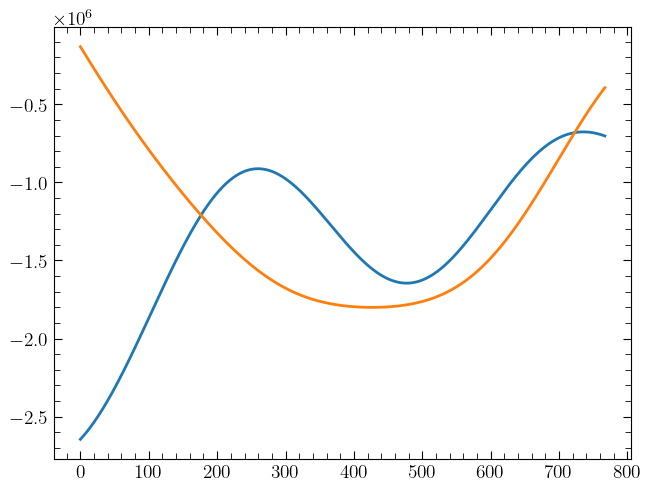

In [4]:
plt.plot(fields_forg[0])
plt.plot(fields_forg[1])


In [5]:
flag_percent = 100 * (1-len(np.nonzero(flag)[0])/N)
print(f'flag percent {flag_percent}')

flag percent 35.286458333333336


In [6]:
# |F(k)|**2

pk_recovered = []

for field in fields_flag:
    fk = np.fft.fft(field)
    pk_fft = (L / N**2) * (fk * fk.conjugate()).real
    pk_recovered.append(pk_fft)
    
pk_recovered = np.array(pk_recovered)
pk_recovered_fft = pk_recovered


In [7]:
# F[C_\ell(\Delta\nu)]

M = np.argmax(ml.real == 0) if np.any(ml.real == 0) else ml.shape[0] # only where cl is valid, ie, discarding last few delta nu
# M = N // 2
M = 640
print(M)


# DCT k-grid the correlation length
k_dct = np.pi * np.arange(M) / ((M-1) * dL)   # k_n = n*pi / L_eff, L_eff = (M-1)*dx

# --- theory on DCT grid (for comparison to pk_dct) ---
P_cont_dct = np.interp(k_dct, k_model, P_model, left=0, right=0)


pk_recovered = []
for field in fields_flag:
    cl_full = pfunc.covtocl_fast(field, field)/ml

    # Use only M-terms of the correlation:
    cl = cl_full[:M]              # shape (M,)
    w = windows.nuttall(2*M)[M:]
    
#     Omi = 1/(4*np.pi*r**2)
#     plt.plot(cl*Omi)
#     plt.plot(cl*Omi*w)
#     plt.show()
    

    # --- DCT estimator (discrete Wiener–Khinchin for half-corr, cosine basis) ---
    pk_dct = dL * idct(cl.real * w, type=1)
    pk_recovered.append(pk_dct)

pk_recovered = np.array(pk_recovered)   # shape (Nrea, M)
pk_recovered_dct = pk_recovered


640


/tmp/ipykernel_3367917/1457753037.py:18: RuntimeWarning: invalid value encountered in divide
  cl_full = pfunc.covtocl_fast(field, field)/ml


In [8]:
ml.shape, M

((768,), 640)

/home/asif/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/asif/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


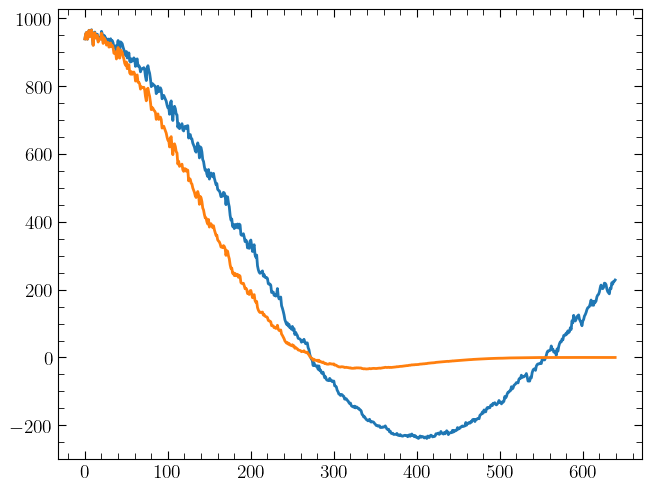

In [9]:
Omi = 1/(4*np.pi*r**2)
plt.plot(cl*Omi)
plt.plot(cl*Omi*w)


In [10]:
n1_fft = 1
nend_fft = N // 2

k_fft_vals = k_abs[n1_fft:nend_fft]
P_theory_fft = P_cont

kb_fft, mean_fft, err_fft, binned_th_fft, bins_fft = pfunc.bin_power_spectrum(
    n1_fft, nend_fft, k_fft_vals, pk_recovered_fft, P_theory_fft, NB
)



n1_dct = 1
nend_dct = M   # from your DCT logic

k_dct_vals = k_dct[n1_dct:nend_dct]
P_theory_dct = P_cont_dct

kb_dct, mean_dct, err_dct, binned_th_dct, bins_dct = pfunc.bin_power_spectrum(
    n1_dct, nend_dct, k_dct_vals, pk_recovered_dct, P_theory_dct, NB
)


In [11]:
path = 'results'
pfunc.save_dct(f"{path}/dct", inp_signal=f"{inp_signal}", flag=f"{mode}", SCF=f"{SCF}", # or GP or DPSS in method
         kb=kb_dct,
         mean=mean_dct,
         err=err_dct,
         binned_th=binned_th_dct)

pfunc.save_dct(f"{path}/fft", inp_signal=f"{inp_signal}", flag=f"{mode}", SCF=f"{SCF}", # or GP or DPSS in method
         kb=kb_fft,
         mean=mean_fft,
         err=err_fft,
         binned_th=binned_th_fft)



Saved: results/dct_inp_signal-FG+21cm_flag-PERIODIC+RANDOM_SCF-None.npz
Saved: results/fft_inp_signal-FG+21cm_flag-PERIODIC+RANDOM_SCF-None.npz


'results/fft_inp_signal-FG+21cm_flag-PERIODIC+RANDOM_SCF-None.npz'

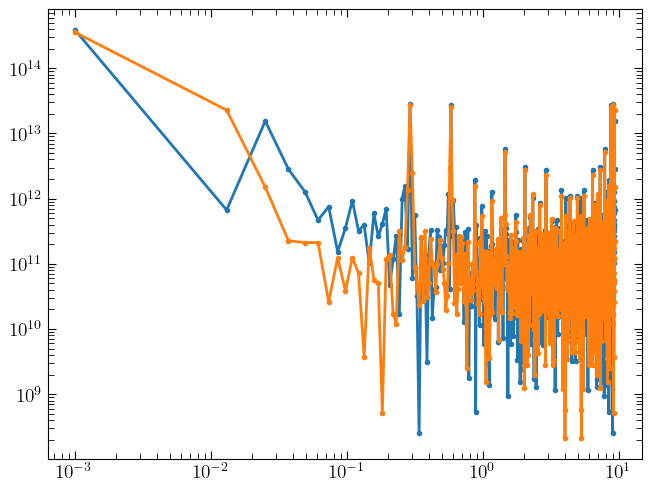

In [12]:
plt.plot(k_fft+0.001, pk_recovered_fft[0][:], '.-')
plt.plot(k_fft+0.001, pk_recovered_fft[1][:], '.-')
plt.xscale('log')
plt.yscale('log')

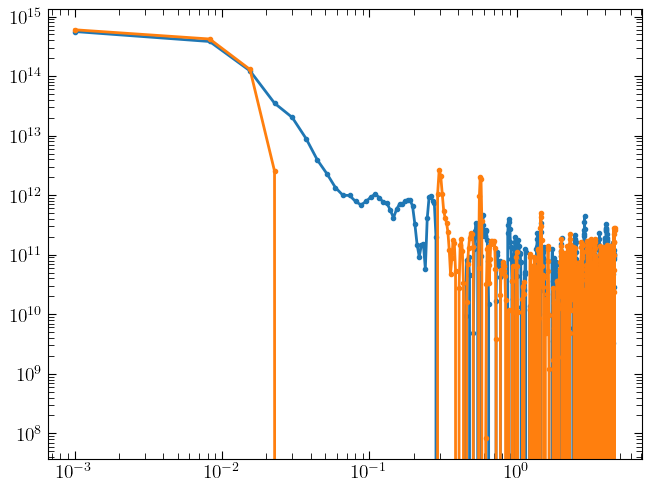

In [13]:
plt.plot(k_dct+0.001, pk_recovered_dct[0][:], '.-')
plt.plot(k_dct+0.001, pk_recovered_dct[1][:], '.-')
plt.xscale('log')
plt.yscale('log')


In [14]:
ml.shape

(768,)